In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import (classification_report, recall_score, confusion_matrix, average_precision_score, 
                             precision_recall_curve, roc_auc_score, cohen_kappa_score, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.inspection import permutation_importance

## Data Preparation

In [2]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local

X = df.drop(columns=['status'])
y = df['status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE oversampling
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [3]:
# ===================
# 2. Base Model (SMOTE outside pipeline)
# ===================
base_lda = LinearDiscriminantAnalysis()
base_lda.fit(X_train_sm, y_train_sm)

y_pred_base = base_lda.predict(X_test)
y_proba_base = base_lda.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lda.predict(X_train_sm)

# Scores for base model
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[514 193]
 [154 450]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.769     0.727     0.748       707
           1      0.700     0.745     0.722       604

    accuracy                          0.735      1311
   macro avg      0.735     0.736     0.735      1311
weighted avg      0.737     0.735     0.736      1311

------------------------------------------------------
Test Average Precision: 0.761
Test AUC: 0.792
Test Cohen's Kappa: 0.470
Training recall: 0.744


## Tuned Model

In [4]:
# ===================
# 3. Tuned Model (SMOTE inside pipeline with GridSearchCV)
# ===================

pipe = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('lda', LinearDiscriminantAnalysis())
])

param_grid = [
    {
        'lda__solver': ['svd'],
        'lda__shrinkage': [None],
        'lda__n_components': [1],
        'lda__tol': [1e-4, 1e-3, 1e-2]
    },
    {
        'lda__solver': ['lsqr', 'eigen'],
        'lda__shrinkage': ['auto', 0.1, 0.5, 0.9],
        'lda__store_covariance': [True, False],
        'lda__n_components': [1], 
        'lda__tol': [1e-4, 1e-3, 1e-2]
    }
]


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,  random_state=42)

grid_lda = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_lda.fit(X_train, y_train) # Notice: no SMOTE here, pipeline handles SMOTE internally

best_lda = grid_lda.best_estimator_
y_pred_tuned = best_lda.predict(X_test)
y_proba_tune = best_lda.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_lda.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=3))

y_train_pred_tuned = best_lda.predict(X_train)

print('------------------------------------------------------')
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 15 folds for each of 51 candidates, totalling 765 fits
Best Parameters: {'lda__n_components': 1, 'lda__shrinkage': 0.1, 'lda__solver': 'lsqr', 'lda__store_covariance': True, 'lda__tol': 0.0001}
------------------------------------------------------
[[510 197]
 [151 453]]
              precision    recall  f1-score   support

           0      0.772     0.721     0.746       707
           1      0.697     0.750     0.722       604

    accuracy                          0.735      1311
   macro avg      0.734     0.736     0.734      1311
weighted avg      0.737     0.735     0.735      1311

------------------------------------------------------
Test Average Precision: 0.756
Test AUC: 0.789
Test Cohen's Kappa: 0.469
Training recall: 0.746


### 95% CI on Recall for the tuned model

Recall 95% CI: (0.715, 0.782)


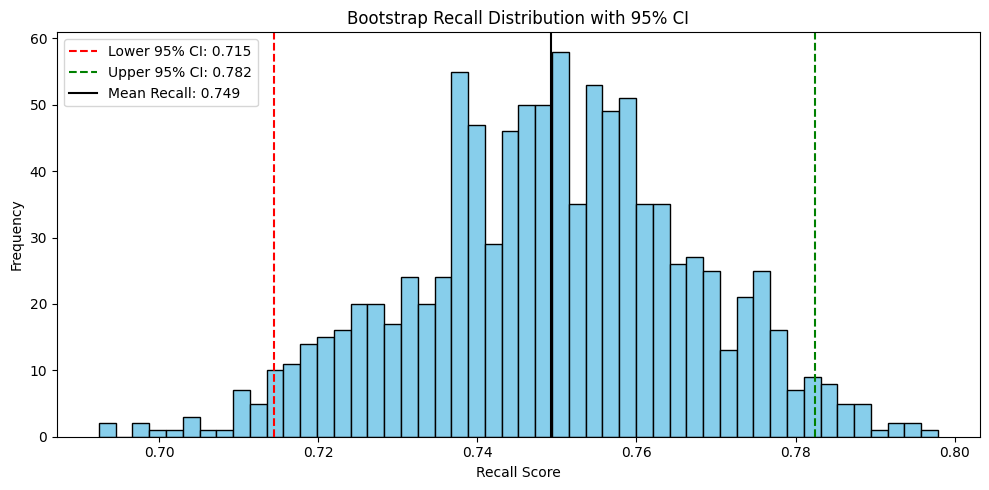

In [5]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_lda.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

             Feature  Coefficient
1       child weight    -1.591181
11             koshi    -0.202916
9            gandaki    -0.194486
6   mother education    -0.178912
4               area    -0.154541
8       wealth index    -0.107361
3              fever    -0.101054
2          diarrhoea     0.010360
13           lumbini     0.043876
14     sudurpashchim     0.111972
7   health insurance     0.136856
12           madhesh     0.223958
10           karnali     0.228742
5          child sex     0.338924
0          child age     0.938267


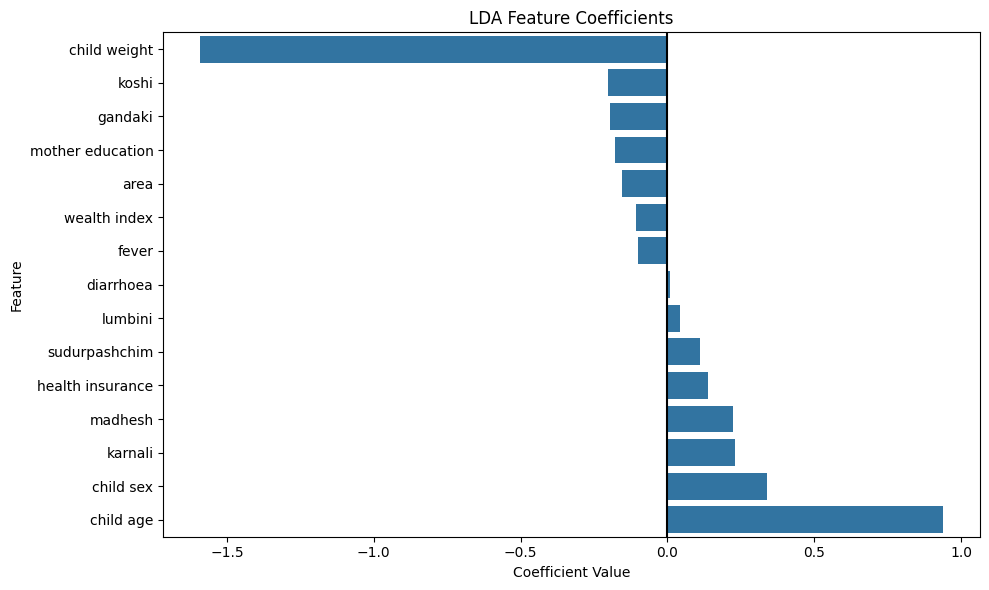

In [6]:

# Extract trained LDA model from the pipeline
lda_model = best_lda.named_steps['lda']

# Get the actual coefficients (can be positive or negative)
coefficients = lda_model.coef_[0]

# Match feature names
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"X{i}" for i in range(X_train.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=True)

print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Coefficient", y="Feature", dodge=False)
plt.axvline(0, color='black')
plt.title("LDA Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Average precision plot

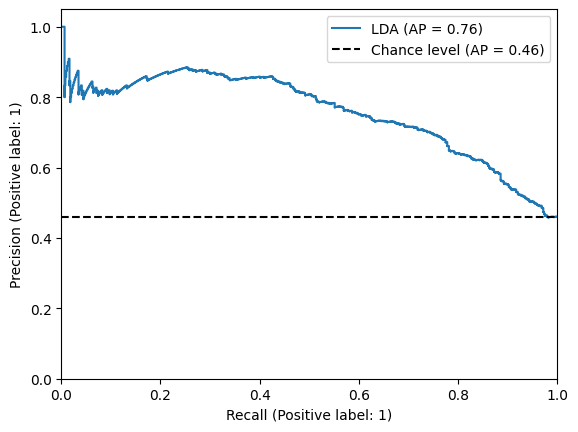

In [11]:
display = PrecisionRecallDisplay.from_estimator(
    best_lda,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="LDA",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

# display.ax_.set_title("LDA Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### Check separability of class 

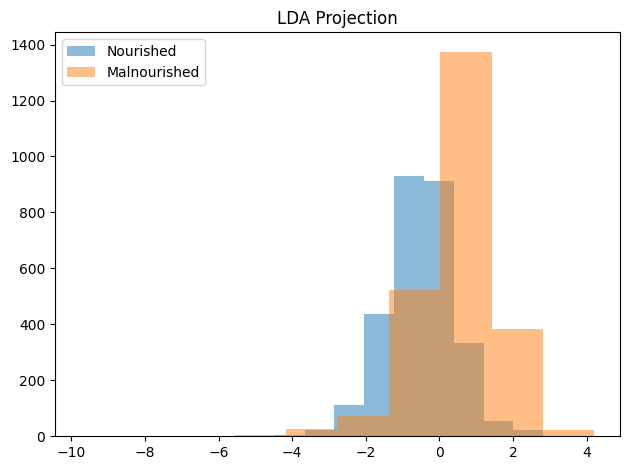

In [13]:
# Project training data
X_lda = base_lda.transform(X_train)

# If 1 component
if X_lda.shape[1] == 1:
    plt.hist(X_lda[y_train == 0], alpha=0.5, label='Nourished')
    plt.hist(X_lda[y_train == 1], alpha=0.5, label='Malnourished')
else:
    plt.scatter(X_lda[y_train == 0, 0], X_lda[y_train == 0, 1], label='Nourished', alpha=0.6)
    plt.scatter(X_lda[y_train == 1, 0], X_lda[y_train == 1, 1], label='Malnourished', alpha=0.6)

plt.title("LDA Projection")
plt.legend()
plt.tight_layout()
plt.show()


### Additional

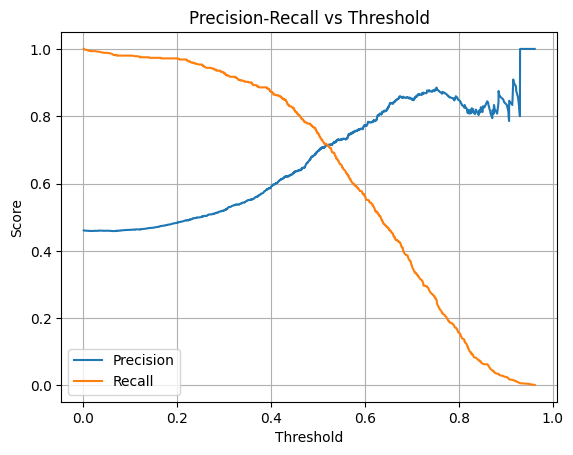

In [9]:
y_proba_tune = best_lda.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [10]:
# Apply custom threshold
y_probas_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.48      0.60       707
           1       0.59      0.87      0.70       604

    accuracy                           0.66      1311
   macro avg       0.70      0.67      0.65      1311
weighted avg       0.71      0.66      0.65      1311


